In [2]:
# Keras: biblioteca de alto nível para construção e treinamento de redes neurais
# Atualmente integrada ao TensorFlow como interface principal
import keras

# applications  → modelos pré-treinados prontos para uso
#                 ex: VGG16, ResNet50, MobileNet, EfficientNet, etc.
# preprocessing → utilitários para preparar dados antes de alimentar o modelo
#                 ex: redimensionar imagens, normalizar pixels, aplicar augmentation
from keras import applications, preprocessing

# numpy: biblioteca para operações matemáticas com arrays e matrizes
# usada para manipular os dados de entrada e saída do modelo
import numpy as np

# pyplot: interface do matplotlib para criação de gráficos e visualização de imagens
from matplotlib import pyplot as plt

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
Top 3 predictions:
	 1. monarch: 0.99
	 2. sulphur_butterfly: 0.01
	 3. admiral: 0.00


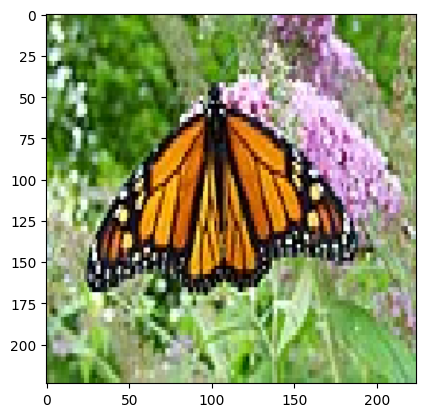

In [8]:
# Carrega o modelo VGG16 pré-treinado no ImageNet
model = applications.vgg16.VGG16(weights='imagenet')

# Nova imagem a ser classificada
img_path = 'teste1.jpeg'

# Carrega e redimensiona para 224x224 (tamanho obrigatório do VGG16)
img = preprocessing.image.load_img(img_path, target_size=(224, 224))

# Pipeline de pré-processamento encadeado (mesmo processo do teste anterior,
# mas agora usando uma variável intermediária 'processed_img' em vez de 'x',
# mantendo 'img' intacto para exibição com plt.imshow() se necessário)

# Converte o objeto PIL para array NumPy: (224, 224, 3)
processed_img = preprocessing.image.img_to_array(img)

# Adiciona a dimensão do batch: (224, 224, 3) → (1, 224, 224, 3)
processed_img = np.expand_dims(processed_img, axis=0)

# Aplica a normalização do VGG16: subtrai a média por canal do ImageNet
processed_img = applications.vgg16.preprocess_input(processed_img)

# Obtém o array bruto de probabilidades: shape (1, 1000)
preds = model.predict(processed_img)

# Decodifica e já acessa o [0] diretamente — mais conciso que o exemplo anterior
# Resultado: lista com 3 tuplas (class_id, class_name, probability)
decoded_preds = applications.resnet50.decode_predictions(preds, top=3)[0]

plt.imshow(img)

print('Top 3 predictions:')
for i, (class_id, class_name, probability) in enumerate(decoded_preds):
    print(f'\t {i+1}. {class_name}: {probability:.2f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Top 3 predictions:
	 1. sports_car: 0.98
	 2. racer: 0.01
	 3. snowmobile: 0.00


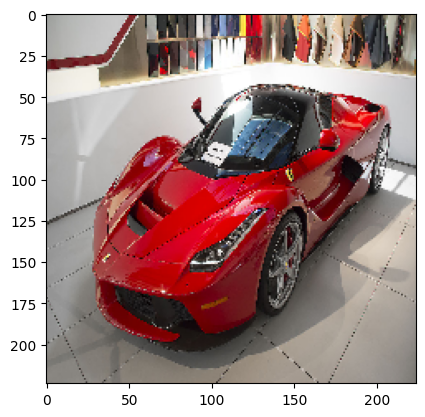

In [ ]:
image_path = 'teste2.jpeg'

# Carrega e redimensiona para 224x224
# O VGG16 também usa 224x224 como entrada, igual ao ResNet50
img = preprocessing.image.load_img(image_path, target_size=(224, 224))

# Converte para array NumPy: (224, 224, 3)
processed_img = preprocessing.image.img_to_array(img)

# Adiciona a dimensão do batch: (224, 224, 3) → (1, 224, 224, 3)
processed_img = np.expand_dims(processed_img, axis=0)

# Aplica o pré-processamento específico do VGG16
# Diferença em relação ao ResNet50:
#   → VGG16:   subtrai a média por canal do ImageNet (sem reescala)
#   → ResNet50: subtrai a média por canal E converte RGB → BGR
# Usar o pré-processamento errado para o modelo escolhido prejudica as previsões
x = applications.vgg16.preprocess_input(processed_img)

# Obtém o array bruto de probabilidades: shape (1, 1000)
preds = model.predict(x)

# Decodifica usando o mapeamento de classes do VGG16
# top=3 → retorna as 3 classes mais prováveis
# [0]   → acessa diretamente as previsões da primeira imagem do batch
decoded_preds = applications.vgg16.decode_predictions(preds=preds, top=3)[0]

# Exibe a imagem original para comparar visualmente com as previsões
plt.imshow(img)

print('Top 3 predictions:')
for i, (class_id, class_name, probability) in enumerate(decoded_preds):
    print(f'\t {i+1}. {class_name}: {probability:.2f}')